Analyze time-series data from platereader experiments.

## Setup

In [ ]:
try:
    import cdk
    print("CDK already installed, skipping installation and restart.")
except ImportError:
    !pip install nucleus-cdk -q > /dev/null 2>&1
    print("\nInstallation complete. Restarting runtime to refresh dependencies...")
    import os
    os._exit(0)

CDK already installed, skipping installation and restart.


In [ ]:

import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.instruments import platereader as pr

from cdk import logging
log = logging.setup_logging(logging.ERROR)

## Load Data

In [ ]:
%%writefile drive_utils.py
import os
import re

import gdown


def get_drive_file_id(url):
    """Extract the file ID from a Google Drive share URL."""
    match = re.search(r'/d/([a-zA-Z0-9_-]+)', url)
    if match:
        return match.group(1)
    return None


def download_from_drive(files_info, destination_dir):
    """
    Download files from Google Drive.

    Args:
        files_info (list): List of dicts with 'url' and 'filename'.
        destination_dir (str): Local path to save files.
    Returns:
        dict: Mapping of filenames to local paths.
    """
    os.makedirs(destination_dir, exist_ok=True)

    paths = {}
    for item in files_info:
        url = item['url']
        filename = item['filename']
        dest = os.path.join(destination_dir, filename)
        file_id = get_drive_file_id(url)

        if file_id:
            gdown.download(id=file_id, output=dest, quiet=True)
        else:
            gdown.download(url, output=dest, quiet=True)

        paths[filename] = dest
    return paths

Overwriting drive_utils.py


In [ ]:
# Set use_drive = True to download data_file and platemap_file from Google Drive instead of
# using local files. Each Drive file must have its permissions set to "Anyone with a link" can "view".
use_drive = True

if use_drive:
    from drive_utils import download_from_drive

    files_to_download = [
        {
            "url": "https://data.nucleus.engineering/platereader/devstudio/20260930-164151-synergy2-luv-gel-OJ.txt",  # Replace with your data file link.
            "filename": "luvgel01_data.txt",

        },
         {
            "url": "https://data.nucleus.engineering/platereader/devstudio/20260930-164151-synergy2-luv-gel-OJ-Day2.txt",  # Replace with your data file link.
            "filename": "luvgel02_data.txt",

        },
         {
            "url": "https://data.nucleus.engineering/platereader/devstudio/20260930-164151-synergy2-luv-gel-OJ-Day2-afterPLA.txt",  # Replace with your data file link.
            "filename": "luvgel02PLA_data.txt",

        },

        {
            "url": "https://drive.google.com/file/d/1FaAVsLXBhn7geS1sKbb9aXfyPDG0_XDb/view?usp=sharing",  # Replace with your platemap file link.
            "filename": "platemap.csv",
        },
    ]
    downloaded_paths = download_from_drive(files_to_download, destination_dir="data")
    data_files = [downloaded_paths[key] for key in downloaded_paths.keys() if key != "platemap.csv"]
    platemap_file = downloaded_paths["platemap.csv"]
else:
    data_file = "sample-data/20251111-122213-cytation5-pure-timecourse-gfp-MFG-98-tRNA-QC.txt"
    platemap_file = "sample-data/platemap.csv"

print(f"Data files: {data_files}\nPlatemap file: {platemap_file}")

Data files: ['data/luvgel01_data.txt', 'data/luvgel02_data.txt', 'data/luvgel02PLA_data.txt']
Platemap file: data/platemap.csv


In [ ]:
pd.read_csv(platemap_file).columns

Index(['Date', 'Experiment Name', 'Well', 'Name', 'Type'], dtype='object')

In [ ]:
# Load data
results = {
    data_file: pr.load_platereader_data(
      data_file=data_file,
      platemap_file=platemap_file,
      platereader="biotek" # options: "biotek"
  ) for data_file in data_files
}

The output is a list of `PlateReaderResult` objects; if you did more than one read on the plate reader, the results will be in separate objects.

In [ ]:
print(results)

{'data/luvgel01_data.txt': PlateReaderResult with the following 1 blocks:
0: (10, 22) endpoint read with reads: CPRG/CPR:412 (Absorbance), CPRG/CPR:570 (Absorbance) (Plate 'Plate 1'), 'data/luvgel02_data.txt': PlateReaderResult with the following 1 blocks:
0: (10, 22) endpoint read with reads: CPRG:412 (Absorbance), CPRG:570 (Absorbance) (Plate 'Plate 1'), 'data/luvgel02PLA_data.txt': PlateReaderResult with the following 1 blocks:
0: (14, 22) endpoint read with reads: CPRG/CPR:412 (Absorbance), CPRG/CPR:570 (Absorbance) (Plate 'Plate 1')}


In [ ]:
res = results["data/luvgel01_data.txt"]
res[0].view().head()

,Date,Experiment,Well,Name,Type,Data,Read,Read Name,Reader Type,Reader ID,Plate Type,Plate ID,Start Time,Read Modality,Absorbance Wavelength (nm)
0,2026-02-10,LUV-Gel,D3,LUV+buffer,Sample,0.154,CPRG/CPR:412,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,412
1,2026-02-10,LUV-Gel,D3,LUV+buffer,Sample,0.102,CPRG/CPR:570,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,570
2,2026-02-10,LUV-Gel,D4,LUV+PEG_gel,Sample,0.186,CPRG/CPR:412,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,412
3,2026-02-10,LUV-Gel,D4,LUV+PEG_gel,Sample,0.089,CPRG/CPR:570,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,570
4,2026-02-10,LUV-Gel,D5,LUV+PEG_pregel,Sample,0.190,CPRG/CPR:412,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,412


Here there were two reads with different gains but the same excitation/emission spectrum, on one plate. If we want just the `GFP-Gext` read, this corresponds to block index 1, so we can extract that block by indexing:

In [ ]:
desired_index = 0
data = {
    k: v[desired_index]
    for k, v in results.items()
}
data

{'data/luvgel01_data.txt': (10, 22) endpoint read with reads: CPRG/CPR:412 (Absorbance), CPRG/CPR:570 (Absorbance),
 'data/luvgel02_data.txt': (10, 22) endpoint read with reads: CPRG:412 (Absorbance), CPRG:570 (Absorbance),
 'data/luvgel02PLA_data.txt': (14, 22) endpoint read with reads: CPRG/CPR:412 (Absorbance), CPRG/CPR:570 (Absorbance)}

You can see the underlying data with `data.view()` (which returns a Pandas DataFrame):

In [ ]:
data['data/luvgel01_data.txt'].view().head()

,Date,Experiment,Well,Name,Type,Data,Read,Read Name,Reader Type,Reader ID,Plate Type,Plate ID,Start Time,Read Modality,Absorbance Wavelength (nm)
0,2026-02-10,LUV-Gel,D3,LUV+buffer,Sample,0.154,CPRG/CPR:412,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,412
1,2026-02-10,LUV-Gel,D3,LUV+buffer,Sample,0.102,CPRG/CPR:570,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,570
2,2026-02-10,LUV-Gel,D4,LUV+PEG_gel,Sample,0.186,CPRG/CPR:412,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,412
3,2026-02-10,LUV-Gel,D4,LUV+PEG_gel,Sample,0.089,CPRG/CPR:570,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,570
4,2026-02-10,LUV-Gel,D5,LUV+PEG_pregel,Sample,0.190,CPRG/CPR:412,CPRG/CPR,Synergy 2,206621,96 well UV-star half-area,Plate 1,2026-09-30 16:42:19,Absorbance,412


## Plot Raw Curves

/tmp/ipykernel_2732/3343472465.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax.set_xticklabels(g.ax.get_xticklabels(), rotation=45, ha='right')


[Text(0, 0, 'LUV+buffer'),
 Text(1, 0, 'LUV+PEG_gel'),
 Text(2, 0, 'LUV+PEG_pregel'),
 Text(3, 0, 'LUV+ULGA'),
 Text(4, 0, 'LUV+LGA')]

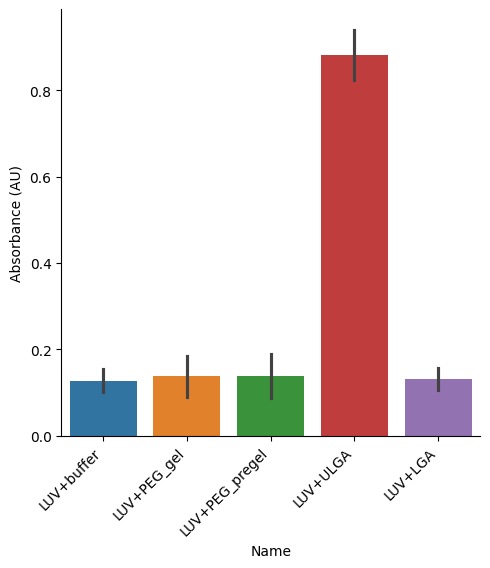

In [ ]:
g = data['data/luvgel01_data.txt'].plot()
g.ax.set_xticklabels(g.ax.get_xticklabels(), rotation=45, ha='right')

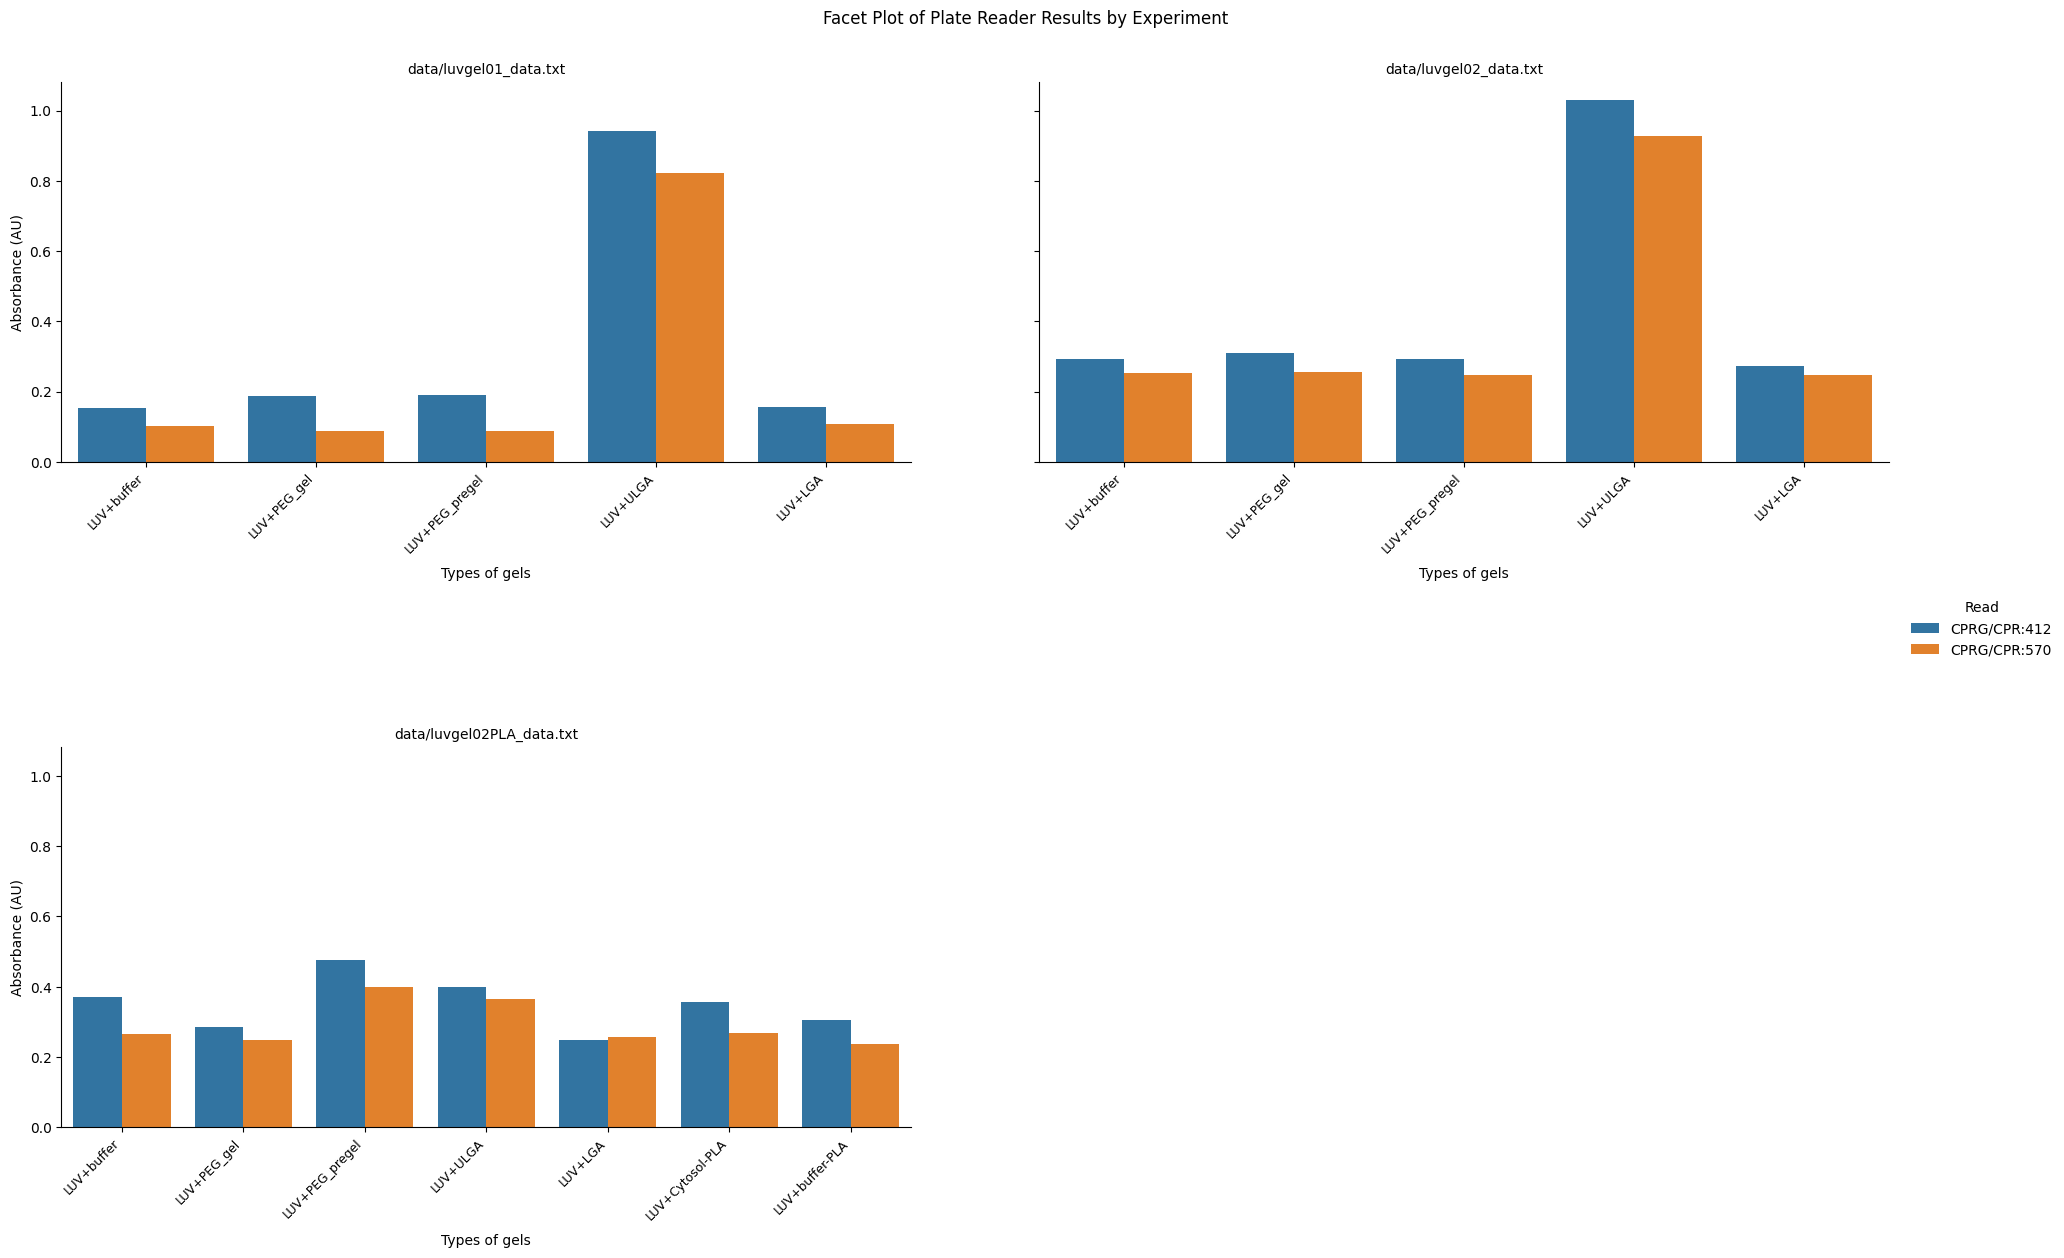

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Consolidate all data into a single DataFrame
all_data_frames = []
for key, result_obj in data.items():
    df = result_obj.view().copy()
    df['Experiment'] = key
    all_data_frames.append(df)

combined_df = pd.concat(all_data_frames, ignore_index=True)

# Standardize 'Read' values so colours are consistent across subplots
combined_df['Read'] = combined_df['Read'].replace({
    'CPRG:412': 'CPRG/CPR:412',
    'CPRG:570': 'CPRG/CPR:570'
})

g = sns.catplot(
    data=combined_df,
    x='Name',
    y='Data',
    hue='Read',
    col='Experiment',
    kind='bar',
    col_wrap=2,
    height=6, aspect=1.6,
    sharex=False,      # stops seaborn hiding x labels/ticks on upper rows
    sharey=True,
    dodge=True
)

g.set_titles("{col_name}")

# Set labels on every subplot, including the top row
for ax in g.axes.flat:
    ax.set_xlabel("Types of gels", labelpad=8)
    ax.set_ylabel("Absorbance (AU)")
    ax.tick_params(labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

# Add vertical space between rows so the top row's x labels aren't covered
g.fig.subplots_adjust(hspace=0.75, wspace=0.15, top=0.92)
g.fig.suptitle('Facet Plot of Plate Reader Results by Experiment', y=0.98)

plt.show()

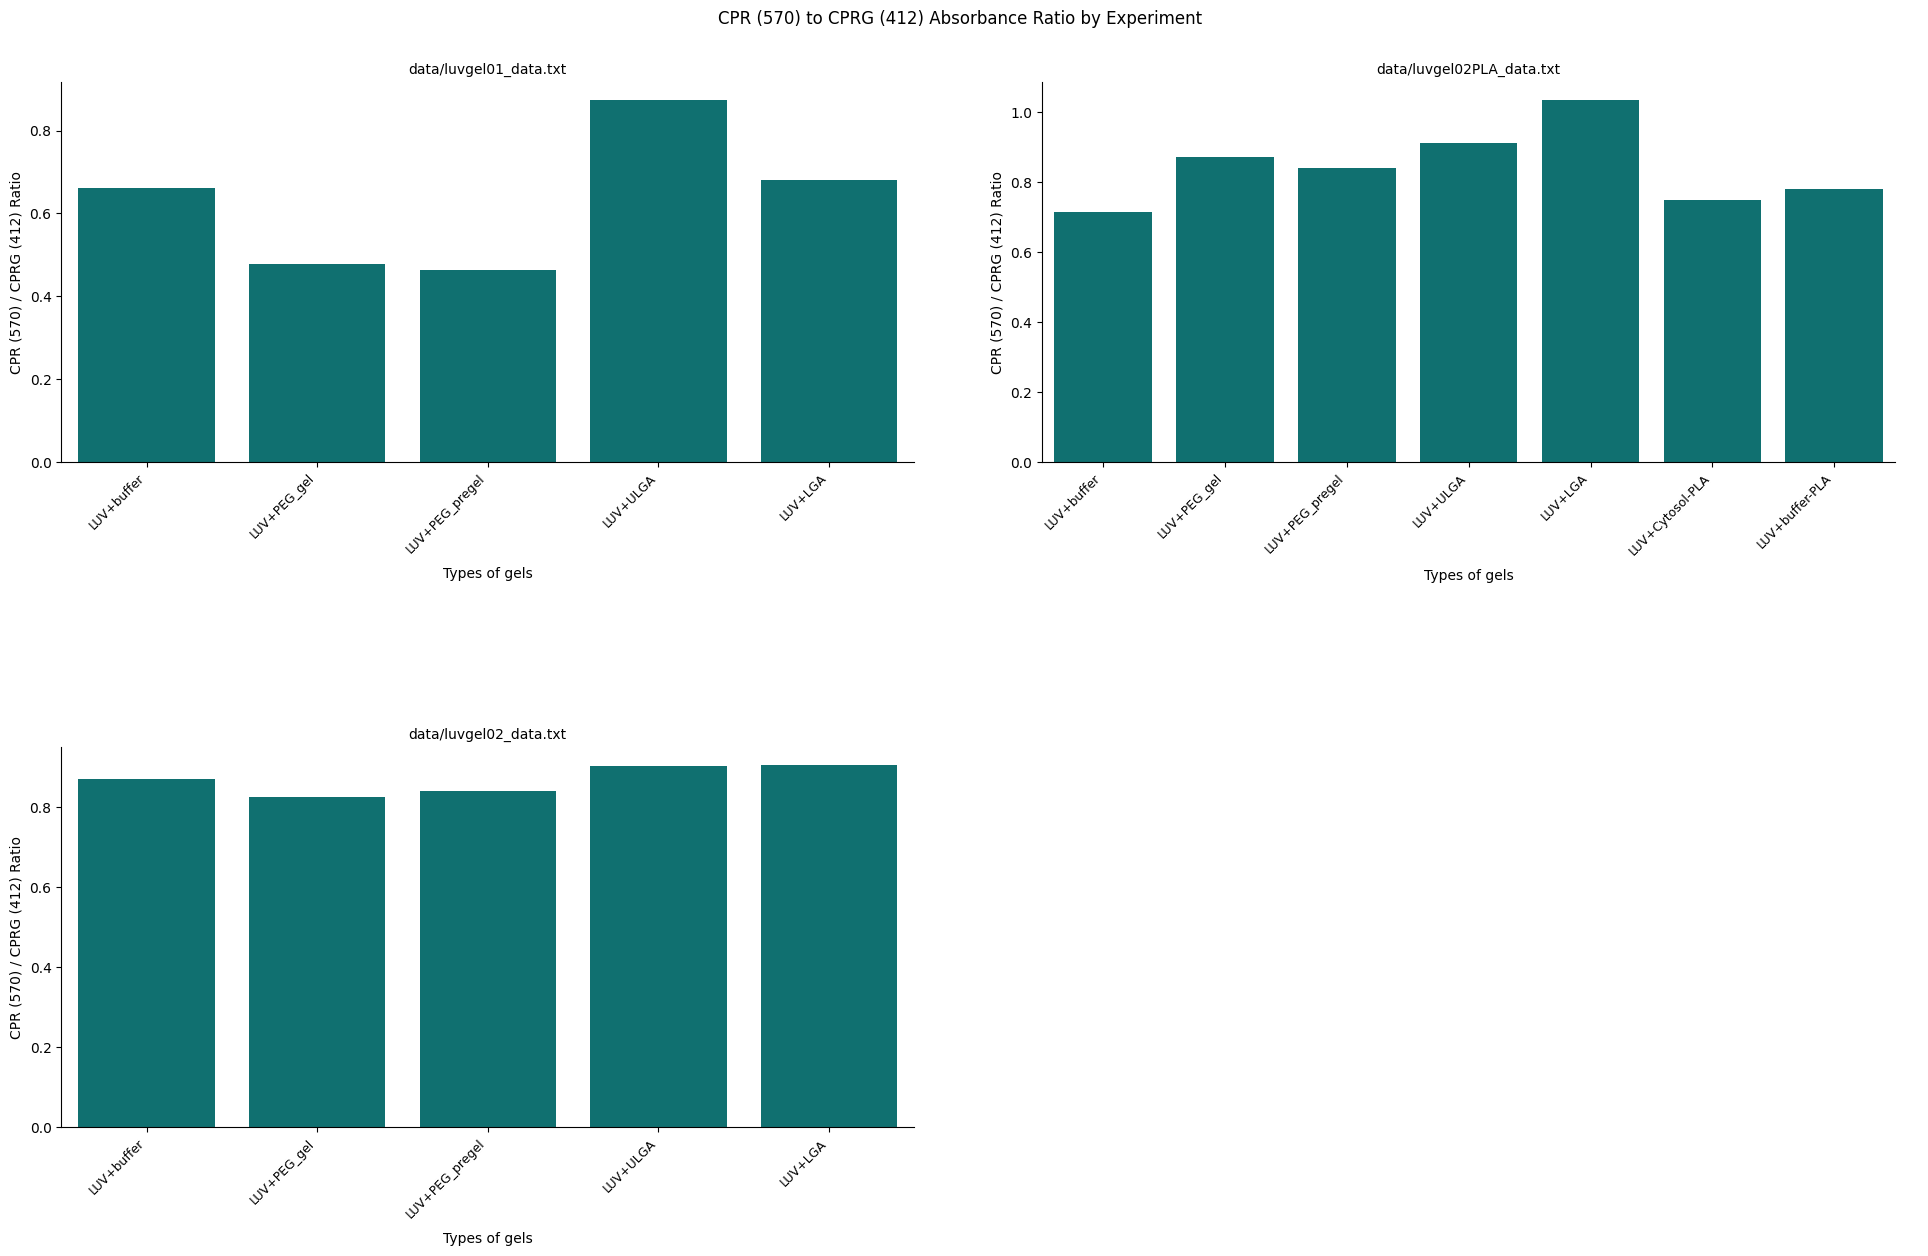

In [ ]:
#| label: op-20261001-fig1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Consolidate all data
all_data_frames = []
for key, result_obj in data.items():
    df = result_obj.view().copy()
    df['Experiment'] = key
    all_data_frames.append(df)

combined_df = pd.concat(all_data_frames, ignore_index=True)

# Standardize 'Read' labels
combined_df['Read'] = combined_df['Read'].replace({
    'CPRG:412': 'CPRG/CPR:412',
    'CPRG:570': 'CPRG/CPR:570'
})

# 2. Pivot the DataFrame to separate the 412 and 570 readings into columns
pivoted_df = combined_df.pivot_table(
    index=['Date', 'Experiment', 'Well', 'Name', 'Type', 'Reader Type', 'Plate ID'],
    columns='Read',
    values='Data'
).reset_index()

# Rename columns for clarity
pivoted_df.columns.name = None
pivoted_df = pivoted_df.rename(columns={
    'CPRG/CPR:412': 'CPRG_412',
    'CPRG/CPR:570': 'CPR_570'
})

# 3. Calculate the ratio: CPR (570) / CPRG (412)
pivoted_df['CPR_CPRG_Ratio'] = pivoted_df['CPR_570'] / pivoted_df['CPRG_412']

# 4. Create the facet plot
g = sns.catplot(
    data=pivoted_df,
    x='Name',
    y='CPR_CPRG_Ratio',
    col='Experiment',
    kind='bar',
    col_wrap=2,
    height=6, aspect=1.6,
    sharex=False,
    sharey=False,
    color='teal'
)

g.set_titles("{col_name}")

# Set labels on every subplot
for ax in g.axes.flat:
    ax.set_xlabel("Types of gels", labelpad=8)
    ax.set_ylabel("CPR (570) / CPRG (412) Ratio")
    ax.tick_params(labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

g.fig.subplots_adjust(hspace=0.75, wspace=0.15, top=0.92)
g.fig.suptitle('CPR (570) to CPRG (412) Absorbance Ratio by Experiment', y=0.98)

plt.show()


### Absorbance Change: luvgel02 to luvgel02PLA

We will extract the data for both `luvgel02_data.txt` and `luvgel02PLA_data.txt`, match the wells/sample names and read wavelengths, calculate the difference in absorbance (Day 2 After PLA minus Day 2 Before PLA), and plot the result.

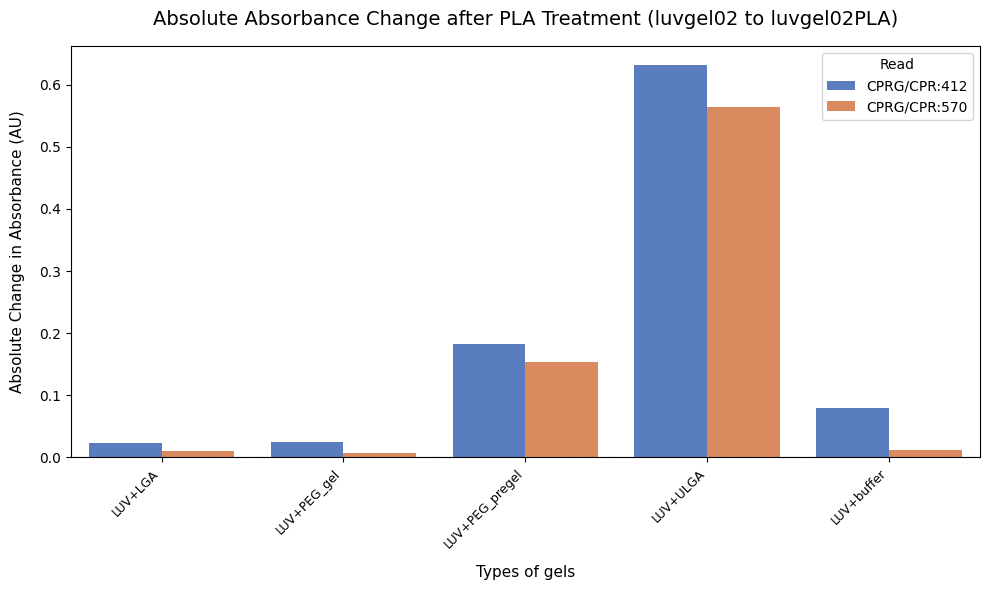

,Name,Read,Data_before,Data_after,Absorbance Change (AU)
0,LUV+LGA,CPRG/CPR:412,0.27,0.25,0.02
1,LUV+LGA,CPRG/CPR:570,0.25,0.26,0.01
2,LUV+PEG_gel,CPRG/CPR:412,0.31,0.28,0.03
3,LUV+PEG_gel,CPRG/CPR:570,0.26,0.25,0.01
4,LUV+PEG_pregel,CPRG/CPR:412,0.29,0.48,0.18
5,LUV+PEG_pregel,CPRG/CPR:570,0.25,0.40,0.15
6,LUV+ULGA,CPRG/CPR:412,1.03,0.40,0.63
7,LUV+ULGA,CPRG/CPR:570,0.93,0.36,0.56
8,LUV+buffer,CPRG/CPR:412,0.29,0.37,0.08
9,LUV+buffer,CPRG/CPR:570,0.25,0.27,0.01


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract and clean the two datasets of interest
df_02 = data['data/luvgel02_data.txt'].view().copy()
df_02PLA = data['data/luvgel02PLA_data.txt'].view().copy()

# Standardize the 'Read' labels for exact matching
for df_temp in [df_02, df_02PLA]:
    df_temp['Read'] = df_temp['Read'].replace({
        'CPRG:412': 'CPRG/CPR:412',
        'CPRG:570': 'CPRG/CPR:570'
    })

# Pivot or group to align matching samples (Name) and measurement wavelengths (Read)
# We average replicates if any exist for a given Name and Read combination
grp_02 = df_02.groupby(['Name', 'Read'])['Data'].mean().reset_index()
grp_02PLA = df_02PLA.groupby(['Name', 'Read'])['Data'].mean().reset_index()

# Merge the two datasets on Name and Read
merged_diff = pd.merge(
    grp_02,
    grp_02PLA,
    on=['Name', 'Read'],
    suffixes=('_before', '_after')
)

# Calculate the absolute magnitude of change in absorbance (no negative values)
merged_diff['Absorbance Change (AU)'] = (merged_diff['Data_after'] - merged_diff['Data_before']).abs()

# Plot the absolute change in absorbance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=merged_diff,
    x='Name',
    y='Absorbance Change (AU)',
    hue='Read',
    palette='muted'
)

plt.title('Absolute Absorbance Change after PLA Treatment (luvgel02 to luvgel02PLA)', fontsize=14, pad=15)
plt.xlabel('Types of gels', fontsize=11, labelpad=10)
plt.ylabel('Absolute Change in Absorbance (AU)', fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# Display the structured calculation table
display(merged_diff[['Name', 'Read', 'Data_before', 'Data_after', 'Absorbance Change (AU)']])

We can see that the standard (here, HPTS) is stable and can be safely used for normalization.

## Normalize Data
Now, use `data.normalize('<standard name>')` to normalize your data. This will calculate the average over a time window at the end of the experiment (by default, 1 hour), then divide all data by the mean of that window-average across all wells with the same `Name` (defined by your platemap).

In [ ]:
# To check the exact name of your standard
platemap = data.platemap
standards = platemap[platemap['Type']=='Standard']
standards['Name'].unique()

In [ ]:
data = data.normalize('10 uM HPTS')

Now replot your curves to see them normalized:

In [ ]:
g = data.plot(style='Type', exclude_types=['Standard'])
# g.savefig('after-normalization.png',dpi=300)

If you want to change the time window over which you calculate the average, you can use the `window` argument:

In [ ]:
# data = data.normalize('10 uM HPTS', window=pd.Timedelta("2.5h"))

## Kinetic Analysis

See the [DevNote](https://devnotes.nucleus.engineering/articles/Newman-20260421) on kinetic analysis for more details.

**Metrics extracted:**

  - **Maximum velocity**: Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level
  - **Time-to-completion**: Time it takes to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit; "Good Fit" is `True` if $R^2 \geq 0.95$

In [ ]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = data.fit_kinetics()

In [ ]:
kinetics.summary

## Visualize Fits

In [ ]:
g = kinetics.plot(col="Well")
# g = kinetics.plot() # call this to visualize across replicates

## Summary Plots

In [ ]:
g = kinetics.plot_summary()

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants